In [1]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
filename = "data/preprocessed_data2.xlsx" # removed an outlier row which had value ~20 for om

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)

for i, col in enumerate(df.columns):
    print(i, col)
spectral_data = df.iloc[:, 1:434]
output_variable = df.iloc[:, 436:437]


0 NaN
1 349.866666666667
2 354.95
3 359.3
4 365.15
5 369.5
6 375.325
7 379.7
8 384.075
9 389.9
10 394.275
11 400.1
12 404.45
13 410.3
14 414.65
15 419
16 424.8
17 429.2
18 434.95
19 439.3
20 445.1
21 449.425
22 455.2
23 459.525
24 465.25
25 469.575
26 475.275
27 479.575
28 485.3
29 489.575
30 495.275
31 499.525
32 505.2
33 509.475
34 515.1
35 519.375
36 525
37 529.2
38 534.8
39 540.4
40 544.6
41 550.2
42 554.4
43 560
44 564.15
45 569.7
46 575.225
47 579.4
48 584.9
49 590.425
50 594.55
51 600.05
52 604.15
53 609.65
54 615.125
55 619.225
56 624.65
57 630.125
58 634.2
59 639.625
60 645.05
61 650.45
62 654.5
63 659.9
64 665.3
65 669.3
66 674.7
67 680.025
68 685.4
69 689.4
70 694.725
71 700.075
72 705.375
73 709.35
74 714.65
75 719.95
76 725.2
77 730.475
78 734.45
79 739.65
80 744.875
81 750.15
82 755.35
83 760.55
84 764.45
85 769.575
86 774.75
87 779.9
88 785.05
89 790.15
90 795.25
91 800.375
92 805.425
93 810.5
94 815.55
95 820.575
96 824.98
97 829.98
98 834.96
99 839.92
100 843.86
101 84

In [5]:
spectral_data.head()
#output_variable.head()

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
0,0.154092,0.145253,0.132048,0.120393,0.117365,0.116590,0.117083,0.118773,0.119548,0.122259,...,0.929058,0.928917,0.921405,0.921029,0.917508,0.912484,0.907742,0.906052,0.904784,0.906521
1,0.220826,0.194554,0.188793,0.163819,0.154851,0.156193,0.157240,0.156618,0.158353,0.162935,...,0.912368,0.911015,0.907437,0.904425,0.904163,0.897574,0.893995,0.893384,0.894562,0.894388
2,0.223714,0.208908,0.189445,0.175717,0.172087,0.169890,0.174863,0.175320,0.178920,0.184015,...,0.925727,0.924954,0.917714,0.917145,0.914013,0.911450,0.908969,0.906650,0.907749,0.907098
3,0.229010,0.193448,0.174742,0.176795,0.164635,0.163062,0.168613,0.165629,0.169800,0.175608,...,0.922672,0.919763,0.913731,0.913431,0.909752,0.906886,0.903463,0.904190,0.902394,0.902522
4,0.274307,0.245903,0.231115,0.219347,0.206839,0.206962,0.207579,0.208688,0.213001,0.217006,...,0.916081,0.912467,0.907127,0.903430,0.902198,0.899569,0.897351,0.893572,0.893982,0.896283


In [6]:
print(spectral_data.shape)
print(output_variable.shape)

(110, 433)
(110, 1)


In [7]:
output_variable.describe()

,OM
count,110.000000
mean,1.237273
std,0.618055
min,0.200000
25%,0.800000
50%,1.100000
75%,1.600000
max,3.200000


Text(0.5, 1.0, 'Output OM Distribution')

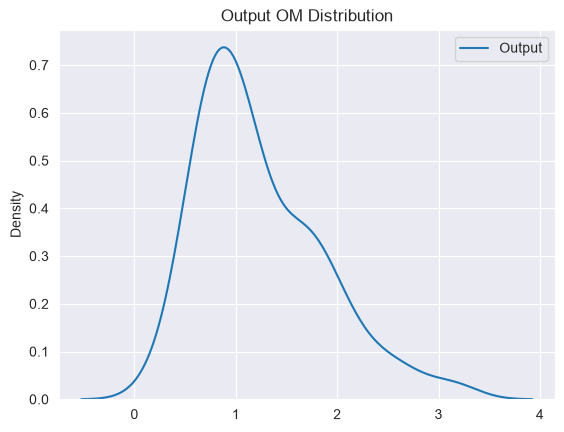

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output OM Distribution")

In [9]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
#
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

In [10]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

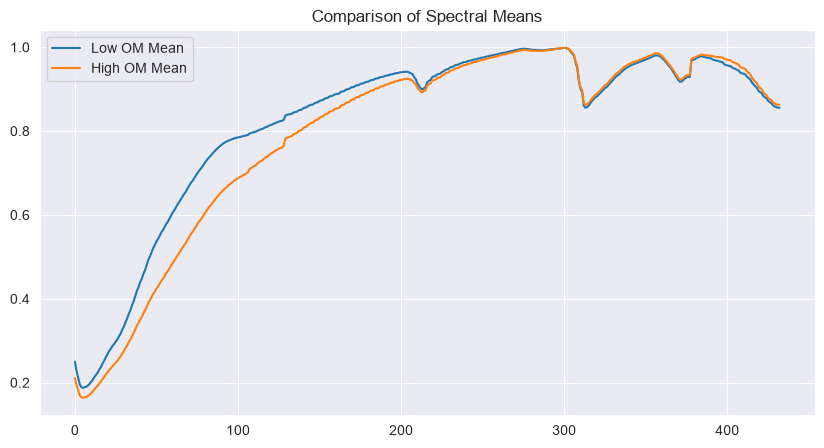

In [11]:

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low OM Mean')
plt.plot(np.mean(high_n, axis=0), label='High OM Mean')
plt.legend()
plt.title("Comparison of Spectral Means")
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)


pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [21]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [22]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.6795
LOOCV RMSE: 0.3483


Train/Test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [24]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
65,0.239411,0.216169,0.194070,0.188055,0.178299,0.172879,0.176096,0.175677,0.178964,0.183125,...,0.864909,0.862345,0.855211,0.851761,0.848917,0.842530,0.840525,0.839080,0.840758,0.838240
26,0.206888,0.185719,0.179242,0.163760,0.160253,0.158420,0.159874,0.158389,0.161801,0.164708,...,0.919810,0.918504,0.915176,0.910585,0.908225,0.903971,0.901022,0.902285,0.900769,0.901948
22,0.196715,0.202006,0.191002,0.167273,0.171493,0.164124,0.164546,0.167597,0.167695,0.168733,...,0.854682,0.851393,0.843429,0.843169,0.838798,0.832652,0.829882,0.822697,0.822437,0.822567
31,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.912659,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.890058
47,0.267072,0.234417,0.230043,0.212151,0.198117,0.203797,0.204435,0.203493,0.209690,0.210693,...,0.882949,0.882139,0.876428,0.872215,0.871972,0.868287,0.866748,0.862697,0.862738,0.862778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.169979,0.159260,0.159609,0.136548,0.133469,0.139208,0.135288,0.134833,0.139033,0.137423,...,0.823908,0.820689,0.811543,0.808324,0.804871,0.801092,0.798199,0.791760,0.791713,0.789287
14,0.222353,0.197319,0.182194,0.171583,0.162161,0.161795,0.165515,0.165088,0.165484,0.171034,...,0.932591,0.929623,0.924419,0.923443,0.922345,0.916206,0.914539,0.913929,0.911490,0.915108
92,0.484347,0.445987,0.432743,0.422104,0.414364,0.417592,0.425773,0.430689,0.439860,0.450756,...,0.975885,0.977059,0.974271,0.970505,0.970603,0.967961,0.966543,0.969380,0.966787,0.969135
51,0.224164,0.221536,0.191704,0.183394,0.178138,0.173911,0.178848,0.180340,0.184317,0.188330,...,0.869522,0.868528,0.859625,0.861520,0.854796,0.847693,0.841679,0.842200,0.841726,0.840116


In [36]:

pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [34]:


pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('regressor', PLSRegression(n_components=10))
# ])

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

Best R2: 0.7511236666429036


In [37]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.8412286102284047
RMSE: 0.3483


Feature selection using lasso

In [38]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.0045)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


C:\Users\berge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.613123e-03, tolerance: 3.132e-03
  model = cd_fast.enet_coordinate_descent(


In [39]:
X_train_selected

array([[0.18679628, 0.73239387, 0.73735926, 0.74099587],
       [0.16963665, 0.60985782, 0.61545024, 0.61971564],
       [0.17558268, 0.5918003 , 0.59770824, 0.60173343],
       [0.17293859, 0.67373784, 0.67929932, 0.6833955 ],
       [0.21631227, 0.70959903, 0.71461118, 0.71846902],
       [0.18876716, 0.75031482, 0.75525752, 0.75878353],
       [0.19488815, 0.64672485, 0.65177739, 0.6552093 ],
       [0.19334303, 0.74136049, 0.7468534 , 0.75092761],
       [0.18728025, 0.79658738, 0.80113754, 0.80465357],
       [0.26132513, 0.6647482 , 0.66979578, 0.67365978],
       [0.1881583 , 0.74182648, 0.74645358, 0.74980213],
       [0.20957157, 0.76284671, 0.76736627, 0.77046186],
       [0.16276962, 0.52794393, 0.53371397, 0.53752039],
       [0.17113755, 0.76833061, 0.77334577, 0.77676697],
       [0.19272968, 0.7545873 , 0.75988398, 0.76313134],
       [0.15026846, 0.69285235, 0.69922819, 0.70348993],
       [0.23244596, 0.76022713, 0.76428746, 0.76724875],
       [0.15793608, 0.59235092,

In [40]:

pls = PLSRegression(n_components=7)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

ValueError: `n_components` upper bound is 4. Got 7 instead. Reduce `n_components`.

Feature Importance from RF

In [41]:

# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=2)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.6162583944769644
RMSE: 0.4051966456373558


RF with GridSearchCV

In [42]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best CV RMSE: -0.48163257829133277


In [43]:
best_rf = grid.best_estimator_

In [44]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: 0.6486439494567595
Test MSE: 0.15032812179027732
